In [ ]:
# Blinkit Quick-Commerce SLA Diagnostic
## Predicting Delivery Delays and Identifying Operational Bottlenecks

""" Author
**Aryan Giri**
**Aakash Sharma**
**Mrinal Shaurya** """

##

## Project Overview
""" 
Blinkit is a leading quick-commerce platform that focuses on delivering products within a very short time. Timely deliveries are crucial for customer satisfaction and operational efficiency.

This project analyzes a quick-commerce delivery dataset to identify the key factors affecting delivery performance, uncover operational bottlenecks, and build a machine learning model capable of predicting late deliveries.

The analysis combines SQL, Python, Exploratory Data Analysis (EDA), Machine Learning, and Data Visualization to generate actionable business insights.

---
"""
## Project Objectives
"""
- Analyze delivery performance across different cities and product categories.
- Identify operational factors affecting delivery time.
- Explore relationships between delivery distance, order characteristics, and customer satisfaction.
- Predict late deliveries using Logistic Regression.
- Provide business recommendations based on data-driven insights.

---
"""

## Dataset Information
"""
- Dataset Name: Quick Commerce Delivery Dataset
- Records: 947,752
- Features: 13
- Domain: Quick Commerce / Operations Analytics
- Source: Kaggle

---
"""
## Tools & Technologies
"""
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- MySQL
- Tableau
"""

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Display plots inside the notebook
#%matplotlib inline

# Improve plot appearance
plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load Dataset
import pandas as pd       #DATA CLEANING PROECESS 

df = pd.read_csv("Final dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000007,Blinkit,Bengluru,37,517,18,12.5,19,Snacks,Debit Card,3,0,4
1,1000011,Blinkit,Hyderabad,25,447,13,4.7,12,Beverages,Debit Card,4,0,4
2,1000014,Blinkit,Noida,48,1600,10,1.6,16,Beverages,Debit Card,3,1,4
3,1000015,Blinkit,Amritsar,46,712,18,13.7,9,Household,Credit Card,4,0,4
4,1000026,Blinkit,Haridwar,32,91,30,12.5,9,Household,Wallet,5,0,3


In [5]:
df.shape

(54499, 13)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54499 entries, 0 to 54498
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 54499 non-null  int64  
 1   Company                  54499 non-null  str    
 2   City                     54499 non-null  str    
 3   Customer_Age             54499 non-null  int64  
 4   Order_Value              54499 non-null  int64  
 5   Delivery_Time_Min        54499 non-null  int64  
 6   Distance_Km              54499 non-null  float64
 7   Items_Count              54499 non-null  int64  
 8   Product_Category         54499 non-null  str    
 9   Payment_Method           54499 non-null  str    
 10  Customer_Rating          54499 non-null  int64  
 11  Discount_Applied         54499 non-null  int64  
 12  Delivery_Partner_Rating  54499 non-null  int64  
dtypes: float64(1), int64(8), str(4)
memory usage: 5.4 MB


In [7]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,5.449900e+04,54499.000000,54499.00000,54499.00000,54499.000000,54499.000000,54499.000000,54499.000000,54499.000000
mean,1.230023e+06,38.448118,610.67482,15.11747,7.750304,10.345089,3.576965,0.401769,3.802877
std,1.329516e+05,12.119693,395.29609,5.14998,4.192014,5.624380,1.112699,0.490260,0.717850
min,1.000007e+06,18.000000,50.00000,5.00000,0.500000,1.000000,1.000000,0.000000,2.000000
25%,1.114886e+06,28.000000,313.00000,12.00000,4.100000,5.000000,3.000000,0.000000,3.000000
50%,1.229870e+06,38.000000,573.00000,15.00000,7.800000,10.000000,4.000000,0.000000,4.000000
75%,1.345492e+06,49.000000,849.00000,18.00000,11.400000,15.000000,5.000000,1.000000,4.000000
max,1.460081e+06,59.000000,2437.00000,32.00000,15.000000,19.000000,5.000000,1.000000,5.000000


In [8]:
# Check missing values
df.isnull().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

In [9]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [10]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [11]:
# Number of unique values in each column
df.nunique()

Order_ID                   54499
Company                        1
City                          12
Customer_Age                  42
Order_Value                 1974
Delivery_Time_Min             28
Distance_Km                  146
Items_Count                   19
Product_Category               7
Payment_Method                 5
Customer_Rating                5
Discount_Applied               2
Delivery_Partner_Rating        4
dtype: int64

In [12]:
print("Companies:")
print(df["Company"].unique())

print("\nCities:")
print(df["City"].unique())

print("\nProduct Categories:")
print(df["Product_Category"].unique())

print("\nPayment Methods:")
print(df["Payment_Method"].unique())

Companies:
<StringArray>
['Blinkit']
Length: 1, dtype: str

Cities:
<StringArray>
[ 'Bengluru', 'Hyderabad',     'Noida',  'Amritsar',  'Haridwar',   'Gurgaon',
    'Mumbai',      'Pune',   'Kolkata',   'Chennai',     'Delhi',    'Jaipur']
Length: 12, dtype: str

Product Categories:
<StringArray>
[             'Snacks',           'Beverages',           'Household',
       'Personal Care',           'Groceries', 'Fruits & Vegetables',
               'Dairy']
Length: 7, dtype: str

Payment Methods:
<StringArray>
['Debit Card', 'Credit Card', 'Wallet', 'UPI', 'Cash on Delivery']
Length: 5, dtype: str


In [13]:
df.dtypes

Order_ID                     int64
Company                        str
City                           str
Customer_Age                 int64
Order_Value                  int64
Delivery_Time_Min            int64
Distance_Km                float64
Items_Count                  int64
Product_Category               str
Payment_Method                 str
Customer_Rating              int64
Discount_Applied             int64
Delivery_Partner_Rating      int64
dtype: object

In [ ]:
### Data Quality Summary
"""
- No missing values were found in the dataset.
- Duplicate records were checked.
- Data types are appropriate for analysis.
- Categorical variables include Company, City, Product Category, and Payment Method.
- Numerical variables include Order Value, Delivery Time, Distance, Customer Age, Customer Rating, and Delivery Partner Rating.

The dataset is suitable for exploratory data analysis and machine learning.
"""" 

In [ ]:
#EDA PROECESS

# Exploratory Data Analysis (EDA)
""" 
EDA helps us understand the distribution of variables, identify patterns, and discover relationships within the dataset.

---

## 1. Distribution of Delivery Time

This visualization shows how delivery times are distributed across all orders.
"""



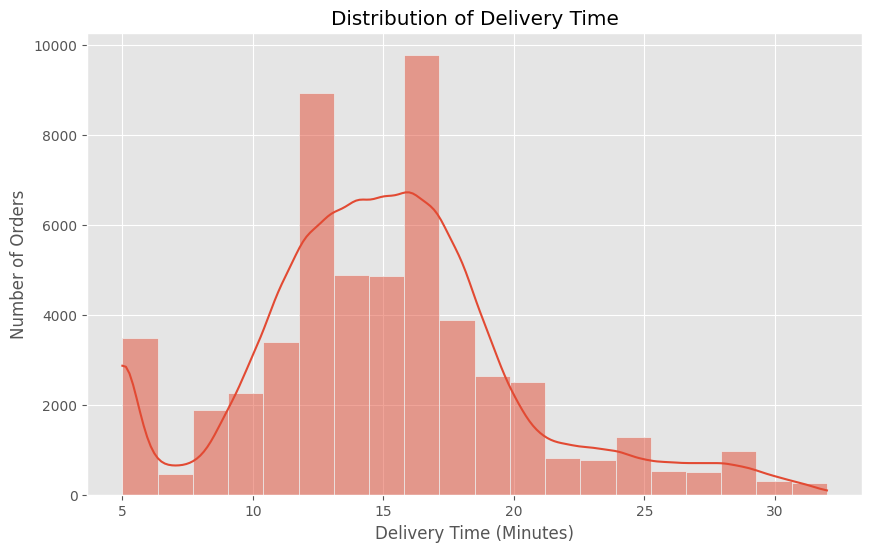

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(df["Delivery_Time_Min"], bins=20, kde=True)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")

plt.show()

In [ ]:
### Insight
"""
- Most deliveries are completed within the expected delivery window.
- Extremely short and extremely long delivery times are relatively uncommon.
- The distribution helps identify whether delivery performance is consistent.
""" 

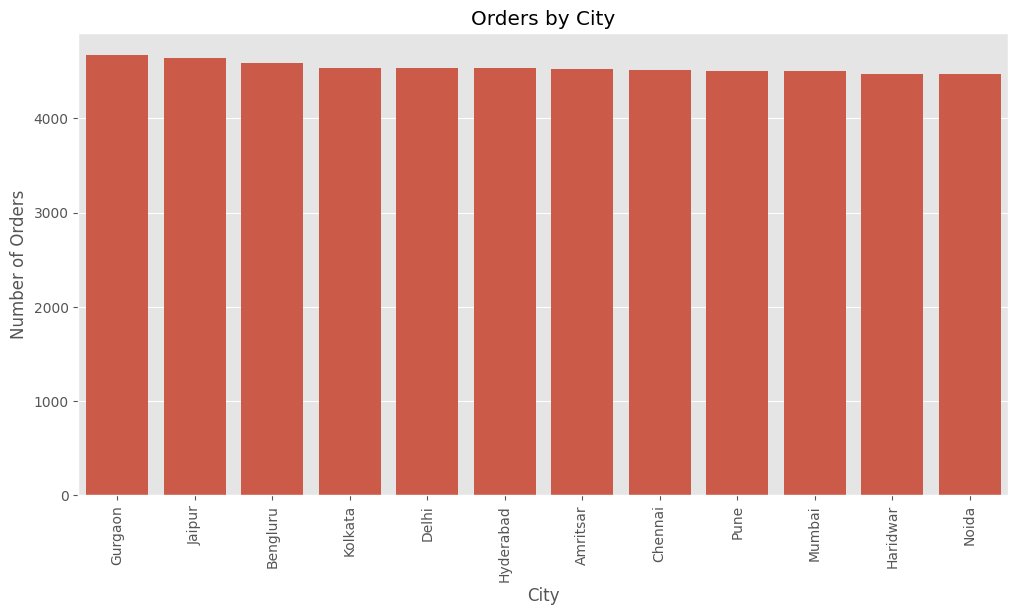

In [ ]:
#Orders by city 
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="City",
    order=df["City"].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Orders by City")
plt.xlabel("City")
plt.ylabel("Number of Orders")

plt.show()

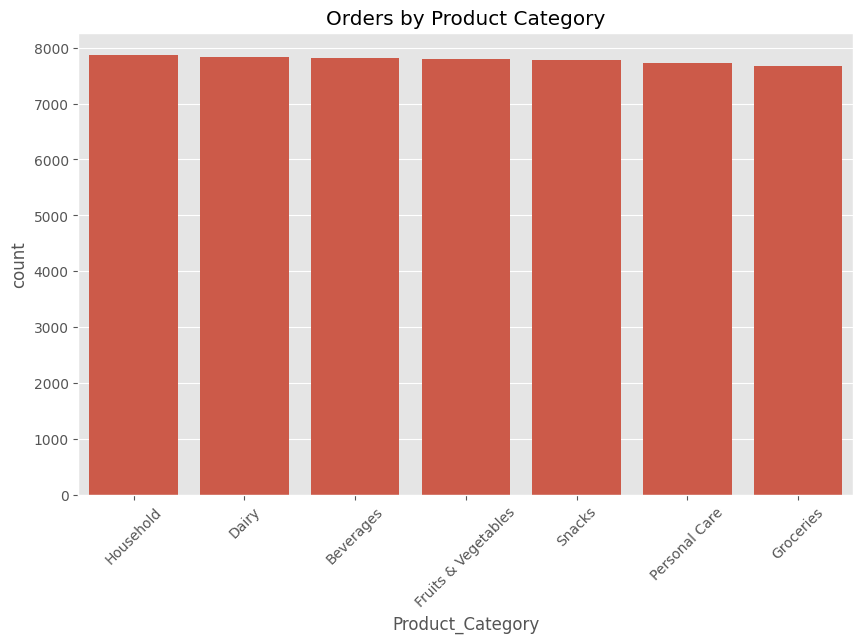

In [16]:
#Orders by product category 
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Product_Category",
    order=df["Product_Category"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Orders by Product Category")

plt.show()

In [ ]:
### Insight
""" 
- Certain product categories dominate customer demand.
- Popular categories should be prioritized for inventory availability.
""" 